In [1]:
# Imports
import re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import mannwhitneyu

In [2]:
# Load
SEED = 123
df = pd.read_csv("../Dati/Processed/dataset_processed_quantile1_sentences.csv")
X, y = df[["text_bert"]], df["binary_label"].values
groups = df["topic_id"].values  # keep triplets together across splits

In [3]:
# Explicit stylometric features (all named -> interpretable coefficients)
FP = {"i","me","my","mine","we","us","our","ours"}
TP = {"he","him","his","she","her","hers","they","them","their","theirs"}
P2 = {"you","your","yours"}
STYLE_NAMES = ["1st-person","2nd-person","3rd-person","exclamation","question","parentheses",
               "quotes","dashes","ALL-CAPS","avg word len","avg sent len","type-token ratio",
               "intensifiers","hedges","absolutes","superlatives", "loaded lang"]

# Lexical-bias lexicons (rates per 1000 tokens -> comparable to the pronoun features)
INTENS = {"very","extremely","totally","absolutely","completely","utterly","incredibly",
          "highly","really","entirely","deeply","terribly","remarkably","so","truly","vastly"}
HEDGES = {"perhaps","maybe","possibly","arguably","seemingly","reportedly","apparently",
          "allegedly","presumably","likely","probably","somewhat","roughly","supposedly"}
ABSOL  = {"always","never","every","everyone","everything","nobody","nothing","all","none",
          "any","must","cannot","everywhere"}
SUP_RE = re.compile(r"\b([a-z]{3,}est|most|least|best|worst)\b")  # superlatives / absolutes of degree
LOADED_WORDS = {
    "illegals","thugs","radical","socialist","communist","marxist","woke","globalist","regime",
    "cabal","tyranny","unborn","invasion","elitist","far-right","far-left","extremist",
    "insurrectionist","oligarch","authoritarian","misinformation","disinformation",
    "slammed","blasted","ripped","eviscerated","shocking","outrageous","bombshell",
    "disgraced","crooked","corrupt","so-called","disastrous","handout",
}
LOADED_PHR = re.compile(r"illegal alien|death tax|climate hoax|deep state|open borders|gun grab|"
                        r"reproductive rights|assault weapon|mainstream media|witch hunt|radical left|radical right")


def style_matrix(frame):
    rows = []
    for t in frame["text_bert"]:
        tok = re.findall(r"[A-Za-z']+", t); low = [w.lower() for w in tok]; n = max(len(tok), 1)
        sents = [s for s in re.split(r"[.!?]+", t) if s.strip()]; ns = max(len(sents), 1)
        rows.append([
            sum(w in FP for w in low)/n*1000, sum(w in P2 for w in low)/n*1000, sum(w in TP for w in low)/n*1000,
            t.count("!")/n*1000, t.count("?")/n*1000, (t.count("(")+t.count(")"))/n*1000,
            (t.count(chr(34))+t.count(chr(8220))+t.count(chr(8221)))/n*1000,
            (t.count("-")+t.count(chr(8211))+t.count(chr(8212)))/n*1000,
            sum(1 for w in tok if len(w) > 1 and w.isupper())/n,
            np.mean([len(w) for w in tok]) if tok else 0, n/ns, len(set(low))/n,
            sum(w in INTENS for w in low)/n*1000, sum(w in HEDGES for w in low)/n*1000,
            sum(w in ABSOL  for w in low)/n*1000, len(SUP_RE.findall(" ".join(low)))/n*1000,
            # --- loaded framing ---
            (sum(w in LOADED_WORDS for w in low) + sum(1 for _ in LOADED_PHR.finditer(t.lower())))/n*1000,
        ])
    return np.array(rows)

In [4]:
# Pipeline + nested grid search
# char TF-IDF (sparse) + standardized style block (dense); both refit per fold -> no leakage
feats = ColumnTransformer([
    ("char", TfidfVectorizer(min_df=0.025, sublinear_tf=True), "text_bert"),
    ("style", Pipeline([("f", FunctionTransformer(style_matrix)), ("s", StandardScaler())]), ["text_bert"]),
])
pipe = Pipeline([("feats", feats),
                 ("clf", LinearSVC(class_weight="balanced", random_state=SEED, max_iter=8000))])

# analyzer + range chosen by CV (unigram/bigram-only ranges underperform ~0.58-0.62, tested apart)
grid = {
    "feats__char__analyzer": ["char", "char_wb"],
    "feats__char__ngram_range": [(1,2),(2,3),(2, 4), (2, 6)],
    "clf__C": [0.5, 1.0],  # kept <=1.0 to avoid low-regularization overfit
}

outer = StratifiedGroupKFold(n_splits=5)
inner = StratifiedGroupKFold(n_splits=5)

gs = GridSearchCV(pipe, grid, scoring="f1_macro", cv=inner, n_jobs=-1)
nested = cross_val_score(gs, X, y, groups=groups, scoring="f1_macro", cv=outer, params={"groups": groups})
print(f"nested f1_macro = {nested.mean():.4f} ± {nested.std():.4f}")

nested f1_macro = 0.6881 ± 0.0116


In [5]:
# Best config + OOF predictions (same group-aware folds)
gs = GridSearchCV(pipe, grid, scoring="f1_macro", cv=outer, n_jobs=-1).fit(X, y, groups=groups)
print(gs.best_params_)
oof = cross_val_predict(gs.best_estimator_, X, y, cv=outer, groups=groups)

{'clf__C': 0.5, 'feats__char__analyzer': 'char_wb', 'feats__char__ngram_range': (2, 3)}


In [6]:
# Classification report + confusion matrix
print(classification_report(y, oof, digits=3))
print(confusion_matrix(y, oof))

              precision    recall  f1-score   support

           0      0.591     0.595     0.593       326
           1      0.797     0.794     0.796       652

    accuracy                          0.728       978
   macro avg      0.694     0.695     0.694       978
weighted avg      0.728     0.728     0.728       978

[[194 132]
 [134 518]]


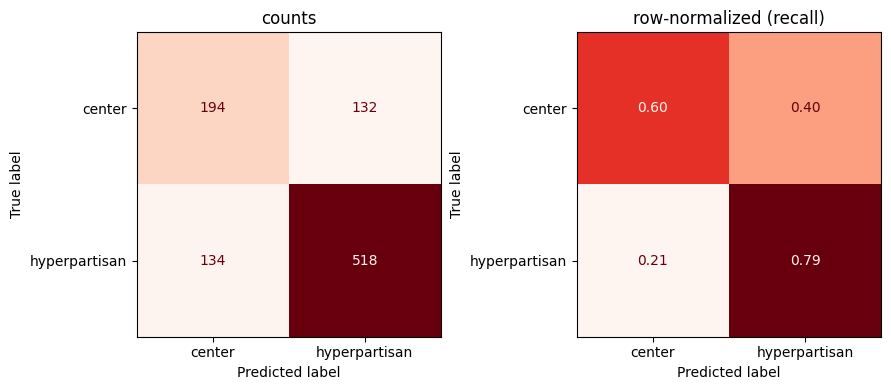

In [7]:
# Confusion matrix (OOF), plotted and row-normalized for per-class recall
from sklearn.metrics import ConfusionMatrixDisplay
labels = ["center", "hyperpartisan"]

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ConfusionMatrixDisplay(confusion_matrix(y, oof), display_labels=labels).plot(
    ax=ax[0], cmap="Reds", colorbar=False, values_format="d")
ax[0].set_title("counts")
ConfusionMatrixDisplay(confusion_matrix(y, oof, normalize="true"), display_labels=labels).plot(
    ax=ax[1], cmap="Reds", colorbar=False, values_format=".2f")
ax[1].set_title("row-normalized (recall)")
plt.tight_layout(); plt.show()

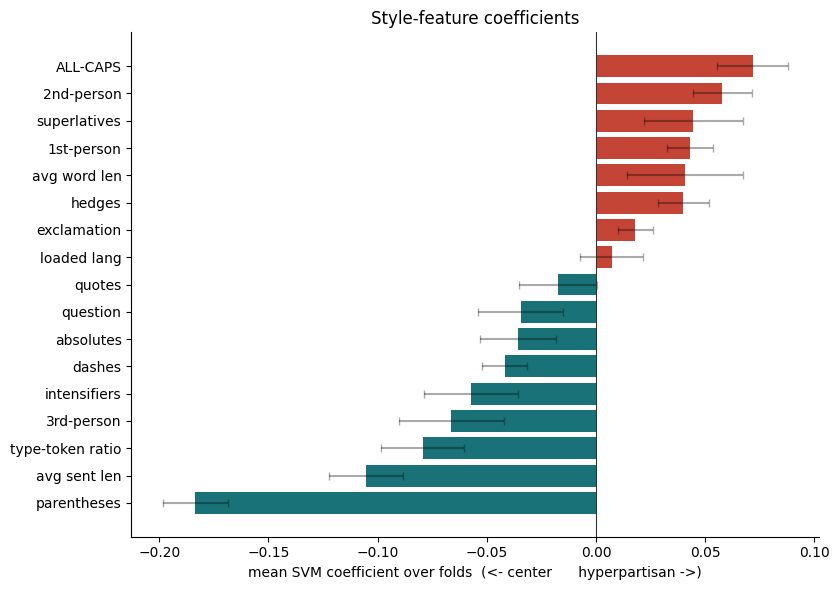

In [10]:
# Interpretation: style-feature coefficients, aggregated over folds (mean +/- std)
# style block = last len(STYLE_NAMES) columns of clf.coef_
best = clone(pipe).set_params(**gs.best_params_)
coefs = []
for tr, _ in outer.split(X, y, groups):
    best.fit(X.iloc[tr], y[tr])
    coefs.append(best.named_steps["clf"].coef_[0][-len(STYLE_NAMES):])

coefs = np.vstack(coefs)
mean, std = coefs.mean(0), coefs.std(0)
order = np.argsort(mean)
col = ["#197278" if mean[i] < 0 else "#c44536" for i in order]

plt.figure(figsize=(8.5, 6))
plt.barh(range(len(STYLE_NAMES)), mean[order], xerr=std[order], color=col, ecolor="#00000055", capsize=3)
plt.yticks(range(len(STYLE_NAMES)), [STYLE_NAMES[i] for i in order])
plt.axvline(0, color="#333", lw=.8)
plt.xlabel("mean SVM coefficient over folds  (<- center      hyperpartisan ->)")
plt.title("Style-feature coefficients")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

         feature    hyp  center  effect  p_holm   sig
type-token ratio  0.654   0.686  -0.154 0.00149  True
     parentheses   4.42    7.94  -0.121 0.00344  True
          hedges   1.17   0.844  0.0703  0.0782 False
      2nd-person   3.36    4.76  0.0672   0.285 False
      1st-person   8.37    7.61  0.0667   0.834 False
          quotes     23    21.6  0.0666   0.923 False
    superlatives   4.31    3.59  0.0664   0.772 False
        ALL-CAPS 0.0471  0.0507 -0.0574       1 False
    intensifiers   1.52    1.59  0.0348       1 False
     loaded lang  0.797   0.563  0.0335       1 False
        question  0.514   0.538   0.025       1 False
     exclamation  0.346   0.225  0.0152       1 False
    avg sent len   19.4    19.7  -0.014       1 False
       absolutes   3.51    4.58  0.0137       1 False
      3rd-person     16    17.1  0.0122       1 False
    avg word len   4.95    4.94  0.0122       1 False
          dashes   13.5    14.5  0.0117       1 False


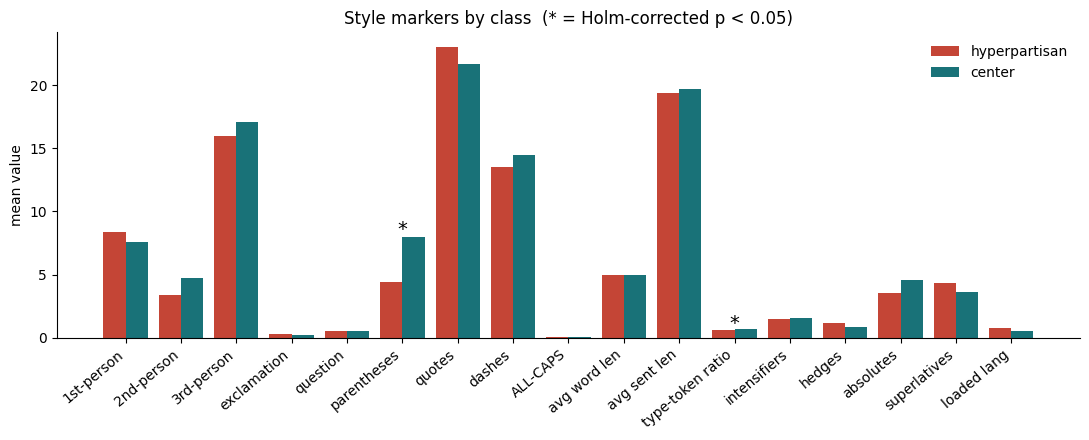

In [12]:
# Style markers by class: Mann-Whitney with effect size + Holm correction
S = style_matrix(X)                       # raw, unscaled
n1, n0 = (y == 1).sum(), (y == 0).sum()
k = len(STYLE_NAMES)                       # number of tests

p_raw, effect = [], []
for j in range(k):
    a, b = S[y == 1, j], S[y == 0, j]
    U, p = mannwhitneyu(a, b)
    p_raw.append(p)
    effect.append(2 * U / (n1 * n0) - 1)  # rank-biserial: >0 -> higher in hyperpartisan
p_raw, effect = np.array(p_raw), np.array(effect)

# Holm step-down correction for k tests (no statsmodels needed)
order_p, p_adj, run_max = np.argsort(p_raw), np.empty(k), 0.0
for rank, j in enumerate(order_p):
    run_max = max(run_max, (k - rank) * p_raw[j])
    p_adj[j] = min(run_max, 1.0)
sig = p_adj < 0.05

# report table, sorted by effect size
tab = (pd.DataFrame({"feature": STYLE_NAMES, "hyp": S[y == 1].mean(0), "center": S[y == 0].mean(0),
                     "effect": effect, "p_holm": p_adj, "sig": sig})
       .sort_values("effect", key=np.abs, ascending=False))
print(tab.to_string(index=False, float_format=lambda v: f"{v:.3g}"))

# bar chart with significance stars on corrected-significant features
m1, m0 = S[y == 1].mean(0), S[y == 0].mean(0)
x, w = np.arange(k), 0.4
plt.figure(figsize=(11, 4.5))
plt.bar(x - w/2, m1, w, label="hyperpartisan", color="#c44536")
plt.bar(x + w/2, m0, w, label="center", color="#197278")
for j in range(k):                        # star above the taller bar
    if sig[j]:
        plt.text(x[j], max(m1[j], m0[j]) * 1.02, "*", ha="center", fontsize=14)
plt.xticks(x, STYLE_NAMES, rotation=40, ha="right")
plt.ylabel("mean value"); plt.title("Style markers by class  (* = Holm-corrected p < 0.05)")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.legend(frameon=False); plt.tight_layout(); plt.show()